ЧАСТЬ 1. Количественный анализ лингвистических особенностей текстов разных уровней CEFR (A1–C1) на основе метрик сложности.

1. Для начала скачаем все нужные библиотеки.

In [3]:
import pandas as pd
import codecs
import nltk
import re
import os

from tqdm import tqdm

from nltk import word_tokenize
from nltk import sent_tokenize
from nltk import download
from nltk.corpus import stopwords
from nltk.tokenize import RegexpTokenizer

import spacy
from spacy.tokens import Doc

import stanza
stanza.download("en")

from collections import Counter

import pickle
import json

from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import matplotlib.pyplot as plt



2025-06-21 08:57:37 INFO: Downloaded file to C:\Users\Марина\stanza_resources\resources.json
2025-06-21 08:57:37 INFO: Downloading default packages for language: en (English) ...
2025-06-21 08:57:38 INFO: File exists: C:\Users\Марина\stanza_resources\en\default.zip
2025-06-21 08:57:42 INFO: Finished downloading models and saved to C:\Users\Марина\stanza_resources


2. Определим рабочую директорию и скорректируем ее.

In [4]:
print(os.getcwd())

c:\Users\Марина\OneDrive\Desktop\Компьютерная лингвистика\Python\Проект


In [5]:
os.chdir('c:/Users/Марина/OneDrive/Desktop/Компьютерная лингвистика/Python/Проект/корпус_текстов')

In [6]:
print(sorted(os.listdir()))

['A1', 'A1_lemmas.txt', 'A1_tokens.txt', 'A2', 'A2_lemmas.txt', 'A2_tokens.txt', 'B1', 'B1_lemmas.txt', 'B1_tokens.txt', 'B2', 'B2_lemmas.txt', 'B2_tokens.txt', 'C1', 'C1_lemmas.txt', 'C1_tokens.txt', 'analyzing_dependencies.json', 'bigrams_tokens.json', 'dependency_analysis.csv', 'dependency_analysis.xlsx', 'lemmatized.json', 'lemmatized.pkl', 'normalized_data.pkl', 'pos-tagged_lemmas.xlsx', 'pos_tags.xlsx', 'processed_data.json', 'processed_data.pkl', 'tf_idf.csv', 'tf_idf.xlsx']


3. Сбор корпуса по  5 уровням английского языка: A1, A2, B1, B2, C1.

In [ ]:
# Создадим функцию, которая проходится по текстам в папке каждого уровня от A1 до C1 и собирает списки из текстов.

def texts_bylevels():
    path= os.getcwd()
    levels = ['A1', 'A2', 'B1', 'B2', 'C1']
    result = []

    for level in levels:
        folder_path = os.path.join(path, level)
        texts = []

        for file_name in sorted(os.listdir(folder_path)):
            full_path = os.path.join(folder_path, file_name)
            with open(full_path, 'r', encoding='utf-8') as file:
                    texts.append(file.read())

        result.append(texts)

    return result[0], result[1], result[2], result[3], result[4]

    
A1, A2, B1, B2, C1 = texts_bylevels()


In [16]:
# Создаем словарь для объединенных текстов

joined_texts = {
    'A1': "\n".join(A1),  
    'A2': "\n".join(A2),
    'B1': "\n".join(B1),
    'B2': "\n".join(B2),
    'C1': "\n".join(C1)
}


# И теперь извлекаем значения из словаря в отдельные переменные. В каждой переменной хранятся соединенные в один текст 40 текстов каждого уровня.

joined_A1 = joined_texts['A1']
joined_A2 = joined_texts['A2']
joined_B1 = joined_texts['B1']
joined_B2 = joined_texts['B2']
joined_C1 = joined_texts['C1']


4. Все этапы предобработки текста до уровня лемм соберем в одну удобную функцию с выводом двух результатов: 1) токены, 2) леммы.

In [50]:
# Создадим функцию обработки текстов для определения лемм

from stanza import DownloadMethod
nlp_stanza = stanza.Pipeline(lang = "en",
                             processors="tokenize, pos, lemma, ner, depparse", tokenize_pretokenized=True, tokenize_no_ssplit=True,
                             download_method=DownloadMethod.REUSE_RESOURCES, # чтобы сэкономить производительные силы компьютера
                             verbose = False) # убирает лишние логи


def normalize(text):
    
     # Воспользуемся spacy для удаления именованных сущностей из текста, пока он един (нам нужен контекст)  
    nlp = spacy.load("en_core_web_sm")
    doc = nlp(text)

    # ИИ подсказал алгоритм, с помощью которого можно склеить токены текста после удаления именованных сущностей без больших пробелов
    # (особенно в словах с апострофом) без использования многочисленных регулярных выражений

    tokens = []
    spaces = []

    for token in doc:
        if not token.ent_type_: 
            tokens.append(token.text)
            spaces.append(bool(token.whitespace_))
    

     
    doc_cleaned = Doc(nlp.vocab, words=tokens, spaces=spaces)
    noent = doc_cleaned.text                                     # Получили текст без именованных сущностей


    # Следующим этапом с помощью RegexpTokenizer уберем пунктуацию и разделим слова на токены
    # Так как в тексте много слов с типографским апострофом " ’ ", заменим его на обычный " ' " для удобной чистки

    text_1 = noent.replace("’", "'")
    pattern = r"\w+(?:'\w+)?"
    tokenizer = RegexpTokenizer(pattern)

    tokenized_text = tokenizer.tokenize(text_1)

    # Почистим текст от стоп-слов (загрузим список стоп-слов и добавим к нему еще слова)

    stop_words = stopwords.words('english') + ['pm', 'mr', 'mrs', 'hi', 'wifi', 'oh']

    lower_tokens = [token.lower() for token in tokenized_text]    # Токены текста без именованных сущностей в нижнем регистре
    clean_tokens = []
    for word in lower_tokens:
        if word not in stop_words and word.isalpha():
            clean_tokens.append(word)
                
    if not clean_tokens:                             # Если после очистки токенов не осталось
        return{'tokens': [], 'lemmas': []}           # Возвращаем пустые списки
    
    # Наконец, получаем список лемм
    
    doc = nlp_stanza([clean_tokens])  
    lemmas = [word.lemma.lower() for sent in doc.sentences for word in sent.words]  
    
    return{'tokens': clean_tokens, 'lemmas' : lemmas}


In [21]:
# Обработаем все тексты функцией normalize, чтобы получить списки токенов и лемм для дальнейшей работы с ними, 
# а также сохраним их в формате pickle, чтобы потом оттуда выгружать данные и не тратить каждый раз производительные силы компьютера.

def normalizing_levels(joined_texts, output_file='normalized_data.pkl'):
    
    normalized_results = {} # Создаем словарь, куда будем выгружать результаты
    
    for level, text in tqdm(joined_texts.items()):
        normalized_results[level] = normalize(text)  
    
# Сохраняем в файл pickle

    with open(output_file, 'wb') as f:
        pickle.dump(normalized_results, f)
    
    print(f"{output_file}")
    return normalized_results


# Запустим обработку и сохранение

normalized_results = normalizing_levels(joined_texts)

100%|██████████| 5/5 [19:45<00:00, 237.11s/it]

normalized_data.pkl


In [47]:
# Создадим функцию, которая будет загружать сохраненные данные и возвращать отдельно токены и леммы

def load_and_extract(file_path='normalized_data.pkl'):
    
    with open(file_path, 'rb') as f: # так как pickle - бинарный формат данных (он быстрее обрабатывается), то сохраняем их в режиме rb
         data = pickle.load(f)
    
    
    # Извлекаем токены и леммы для каждого уровня

    tokens = {level: data[level]['tokens'] for level in data}
    lemmas = {level: data[level]['lemmas'] for level in data}
    
    return tokens, lemmas

5. Подсчет показателя TTR (type-token ratio), то есть коэффициента лексического разнообразия.

In [ ]:
# Создаём таблицу

df = pd.DataFrame([
    {
        'Level': level,
        'Total': len(normalized_data[level]['lemmas']),           # Подсчет общего количества лемм
        'Unique': len(set((normalized_data[level]['lemmas'])))    # Подсчет уникальных лемм
    }
    for level in ['A1', 'A2', 'B1', 'B2', 'C1']
])

# Вычислим показатель TTR
df['TTR'] = (df['Unique'] / df['Total'] * 100).round(1)           # Считаем показатель TTR: разделим общее количество лемм на количество уникальных лемм, округлим

print(df)

  Level  Total  Unique   TTR
0    A1   3667     853  23.3
1    A2   5361    1305  24.3
2    B1   6349    2001  31.5
3    B2   8950    2762  30.9
4    C1  10381    3324  32.0


Как видно из показателя, уровень лексического разнообразия растет с повышением уровня английского языка.

6. Синтаксический разбор.

In [ ]:
# Для анализа синтаксической сложности текстов каждого уровня будем использовать Stanza с названиями зависимостей в формате Universal Dependencies.

def analyzing_dependencies(doc):
        
    counters = {
               
        # Синтаксическая сложность
        'conj': 0,        # союзы (сложные предложения)
        'advcl': 0,       # обстоятельственные придаточные
        'acl': 0,         # определительные придаточные
        'ccomp': 0,       # дополнительные придаточные
        'xcomp': 0,       # открытые дополнения 
        
        # Морфология и времена
        'aux': 0,         # вспомогательные глаголы
        'auxpass': 0,     # пассивные конструкции
        'cop': 0,         # глаголы-связки (is, seem)
        'modals': 0,      # модальные глаголы (can, should)
        
        # Лексика
        'compound': 0,    # составные слова
                
        # Статистика
        'avg_sent_len': sum(len(s.words) for s in doc.sentences) / len(doc.sentences),  # средняя длина предложения
        'total_words': sum(len(s.words) for s in doc.sentences),                        # всего слов
        'unique_words': len({w.text.lower() for s in doc.sentences for w in s.words}),  # количество уникальных слов
    }
    
    # Подсчет зависимостей
    for sentence in doc.sentences:
        for word in sentence.words:
                           
            # Синтаксис
            if word.deprel == 'conj':
                counters['conj'] += 1
            elif word.deprel == 'advcl':
                counters['advcl'] += 1
            elif word.deprel == 'acl':
                counters['acl'] += 1
            elif word.deprel == 'ccomp':
                counters['ccomp'] += 1
            elif word.deprel == 'xcomp':
                counters['xcomp'] += 1
            
            
            # Глаголы и времена
            elif word.deprel == 'aux':
                counters['aux'] += 1
            elif word.deprel == 'auxpass':
                counters['auxpass'] += 1
            elif word.deprel == 'cop':
                counters['cop'] += 1
            elif word.upos == 'AUX' and word.text.lower() in {'can', 'could', 'may', 'might', 'must', 'shall', 'should', 'will', 'would'}:
                counters['modals'] += 1
            
            # Лексика
            elif word.deprel == 'compound':
                counters['compound'] += 1

    return counters



In [ ]:
# Пройдемся по текстам всех уровней и применим к ним функцию анализа зависимостей
results = {}
for level, text in tqdm(joined_texts.items()):
    doc = nlp_stanza(text)                        
    results[level] = analyzing_dependencies(doc)  

  0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 5/5 [14:06<00:00, 169.39s/it]


In [ ]:
# Сохраним результаты анализа

with open('analyzing_dependencies.json', 'w', encoding='utf-8') as f:
    json.dump(results, f, ensure_ascii=False, indent=2)


In [ ]:
# Откроем результаты(при последующем открытии файла):

with open('analyzing_dependencies.json', 'r', encoding='utf-8') as f:
    loaded_results = json.load(f)

In [ ]:
# Оформим результаты в датафрейм

df_dependencies = pd.DataFrame.from_dict(results, orient='index')


# Добавим сортировку столбцов, чтобы было все нагляднее

column_order = [
    # Статистика
    'total_words', 'unique_words', 'avg_sent_len',
    
    # Синтаксическая сложность
    'conj', 'advcl', 'acl', 'ccomp', 'xcomp',
    
    # Морфология и времена
    'aux', 'auxpass', 'cop', 'modals',
    
    # Лексика
    'compound'
]
df_dependencies = df_dependencies[column_order]

# Посчитаем некоторые метрики

df_dependencies['lexical_diversity'] = df_dependencies['unique_words'] / df_dependencies['total_words']  # Лексическое разнообразие
df_dependencies['complexity_score'] = df_dependencies[['conj', 'advcl', 'acl', 'ccomp', 'xcomp']].sum(axis=1)  # Общий показатель сложности

# Сохраним в разных форматах на всякий случай
df_dependencies.to_csv('dependency_analysis.csv', float_format='%.2f')  
df_dependencies.to_excel('dependency_analysis.xlsx', float_format='%.2f') 

# Наконец, оформим результаты в красивую табличку

display(df_dependencies.style
       .background_gradient(cmap='Blues', subset=['complexity_score', 'lexical_diversity'])
       .format('{:.2f}', subset=pd.IndexSlice[:, df_dependencies.select_dtypes(include='number').columns]))



,total_words,unique_words,avg_sent_len,conj,advcl,acl,ccomp,xcomp,aux,auxpass,cop,modals,compound,lexical_diversity,complexity_score
A1,8593.00,2083.00,26.36,474.00,134.00,29.00,99.00,153.00,104.00,0.00,314.00,1.00,250.00,0.24,889.00
A2,12406.00,3110.00,31.17,577.00,318.00,67.00,221.00,274.00,311.00,0.00,342.00,2.00,343.00,0.25,1457.00
B1,14276.00,4067.00,46.65,691.00,342.00,148.00,123.00,256.00,336.00,0.00,325.00,2.00,755.00,0.28,1560.00
B2,17846.00,5255.00,58.13,838.00,530.00,222.00,202.00,379.00,487.00,0.00,411.00,1.00,773.00,0.29,2171.00
C1,22395.00,6304.00,39.71,964.00,554.00,251.00,281.00,391.00,605.00,0.00,516.00,2.00,854.00,0.28,2441.00


In [ ]:
# Посчитаем POS- теги и частотность 

# Анализ текста

data = []

for level, text in joined_texts.items():
    print(f'\nАнализ текста уровня {level}:')
    doc = nlp_stanza(text)
    pos_counts = Counter([word.upos for sentence in doc.sentences for word in sentence.words])

    print("Распределение частей речи:")
    for tag, count in pos_counts.items():
        print(f"{tag}: {count}")
        data.append([tag, count, level])



Анализ текста уровня A1:
Распределение частей речи:
PRON: 1010
AUX: 431
VERB: 1068
ADP: 828
ADJ: 688
NOUN: 1952
INTJ: 46
ADV: 421
NUM: 113
CCONJ: 398
DET: 869
SCONJ: 68
PUNCT: 140
PART: 156
PROPN: 399
SYM: 3
X: 3

Анализ текста уровня A2:
Распределение частей речи:
AUX: 696
PRON: 1385
NOUN: 2699
VERB: 1762
ADP: 1202
PART: 279
SCONJ: 227
CCONJ: 517
DET: 1057
ADJ: 760
ADV: 664
PUNCT: 214
PROPN: 670
NUM: 194
INTJ: 73
SYM: 3
X: 4

Анализ текста уровня B1:
Распределение частей речи:
ADJ: 1210
CCONJ: 596
NOUN: 3353
X: 6
SCONJ: 258
PRON: 1058
VERB: 1719
DET: 1445
AUX: 799
ADP: 1528
ADV: 664
PART: 319
PROPN: 924
NUM: 197
PUNCT: 153
INTJ: 46
SYM: 1

Анализ текста уровня B2:
Распределение частей речи:
NOUN: 4380
SCONJ: 484
DET: 1650
VERB: 2324
ADJ: 1601
ADP: 1892
AUX: 1092
PUNCT: 176
PART: 476
PRON: 1339
ADV: 926
CCONJ: 700
PROPN: 587
NUM: 181
INTJ: 37
SYM: 1

Анализ текста уровня C1:
Распределение частей речи:
ADJ: 1798
PROPN: 841
ADP: 2555
NUM: 316
DET: 2199
NOUN: 5179
ADV: 1330
AUX: 1377
PRO

In [132]:
# Оформим результаты в табличку

df_pos = pd.DataFrame(data, columns=['tag', 'count', 'level'])
df_pos


,tag,count,level
0,PRON,1010,A1
1,AUX,431,A1
2,VERB,1068,A1
3,ADP,828,A1
4,ADJ,688,A1
...,...,...,...
79,CCONJ,860,C1
80,PUNCT,250,C1
81,INTJ,46,C1
82,X,4,C1


In [ ]:
# И сохраним ее

df_pos.to_excel('pos_tags.xlsx', index=False)  

7. Подсчет и сравнение косинусных расстояний между текстами разных уровней английского языка.

In [ ]:
# Для подсчета косинусных расстояний создадим мешок слов для каждого уровня. 
# Для этого необходимо объединить леммы каждого уровня в одну строку.

# Загружаем сохранённые данные
with open('normalized_data.pkl', 'rb') as f:
    normalized_data = pickle.load(f)

# Соединяем леммы каждого уровня в одну строку
lemmas_by_level = {
    level: ' '.join(data['lemmas']) 
    for level, data in normalized_data.items()
}

# Подготовим данные для CountVectorizer

levels = list(lemmas_by_level.keys())
texts = list(lemmas_by_level.values())

In [ ]:
# Создаём модель мешка слов с помощью библиотеки sklearn

from sklearn.feature_extraction.text import CountVectorizer    # Импорт функции, которая создаст вектора мешка слов
vectorizer = CountVectorizer()                                 # Сохраним в переменную
X = vectorizer.fit_transform(texts)                            # Создадим модель мешка слов
len(vectorizer.get_feature_names_out())                        # Количество уникальных лемм в нашей модели

5393

In [ ]:
# Оформим результаты в табличку

text_vector = pd.DataFrame(columns = vectorizer.get_feature_names_out(), data = X.toarray())
text_vector

,abandon,abandonment,abdel,ability,abject,able,aboard,abroad,abruptly,absence,...,young,youth,youthful,youtube,zeppelin,zipped,zombie,zone,zoo,ºc
0,0,0,0,0,0,0,0,0,0,0,...,6,0,0,0,0,0,0,0,1,0
1,0,0,0,1,0,2,0,1,0,0,...,8,0,0,0,0,0,1,1,2,1
2,0,0,2,2,0,6,0,0,0,0,...,3,0,0,0,0,0,1,0,0,0
3,1,0,0,2,1,13,0,2,0,1,...,7,2,1,1,1,0,0,2,0,0
4,6,1,0,7,0,10,1,0,1,0,...,7,0,0,0,0,1,0,0,0,0


In [ ]:
# Создадим векторы

vector_1 = [X.toarray()[0]]
vector_2 = [X.toarray()[1]]
cosine_similarity(vector_1, vector_2)

array([[0.75070724]])

<Axes: >

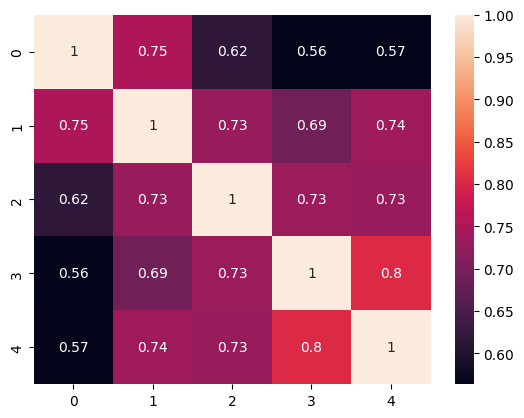

In [ ]:
# Нарисуем тепловой график с помощью seaborn для визуального представления данных

matrix_alt = cosine_similarity(X.toarray())
sns.heatmap(matrix, annot=True)

# 0- минимальная схожесть, 1- максимальная


Как видно из графика, самая минимальная схожесть с другими уровнями у уровня А1(0 на графике) - самого начального. Самая максимальная схожесть у уровней B2(3 на графике) и C1(4 на графике).

8. Посчитаем показатель tf-idf(term frequency-inverse document frequency).
Tf-idf помогает оценить важность слов в текстах. Высокий tf-idf показывает, что слово редко встречается в других уровнях. Если он нулевой - слово есть во всех уровнях и оно неинформативно.

In [38]:
# С помощью импортированного TfidfVectorizer получим вектора лемм в текстах

tfidf_vectorizer = TfidfVectorizer(ngram_range=(1, 1),  # (1,1) означает униграммы
                                   min_df=0.01,         # игнорирует слова, которые встречаются реже чем 1% текстов
                                   max_df=0.9,           # игнорирует слова, которые встречаются в >90% текстов
                                   token_pattern=r'\b[a-zA-Z]{3,}\b'  # Только слова из 3+ букв                                                 
                                   ) 

In [52]:
# Для более чистых результатов будем использовать списки лемм

tokens, lemmas = load_and_extract('normalized_data.pkl')

lemmatized_texts = {
    level: ' '.join(level_lemmas)               # Объединяем леммы через пробел
    for level, level_lemmas in lemmas.items()
}


In [54]:
# Преобразуем тексты в матрицу tf-idf

texts_for_tfidf = [
    lemmatized_texts['A1'],
    lemmatized_texts['A2'],
    lemmatized_texts['B1'],
    lemmatized_texts['B2'],
    lemmatized_texts['C1']
]

tfidf_matrix = tfidf_vectorizer.fit_transform(texts_for_tfidf)
tfidf_matrix

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 8432 stored elements and shape (5, 5012)>

In [55]:
# Преобразуем разреженную матрицу (хранит только ненулевые значения) в плотную (все значения явные)

npm_tfidf = tfidf_matrix.todense()

# Создадим словарь, в котором ключи - это уровни A1-C1, а значения - tf-idf вектора

document_vectors = {
    'A1': np.array(npm_tfidf[0]).flatten(),
    'A2': np.array(npm_tfidf[1]).flatten(),
    'B1': np.array(npm_tfidf[2]).flatten(),
    'B2': np.array(npm_tfidf[3]).flatten(),
    'C1': np.array(npm_tfidf[4]).flatten()
}

# Выводим список всех слов, которые учитывает векторизатор

print(tfidf_vectorizer.get_feature_names_out())

# Печатаем tf-idf вектора для каждого уровня

for level, vector in document_vectors.items():
    print(f"\nВектор TF-IDF для {level}:")
    print(vector) 


['abandon' 'abandonment' 'abdel' ... 'zombie' 'zone' 'zoo']

Вектор TF-IDF для A1:
[0.         0.         0.         ... 0.         0.         0.01543367]

Вектор TF-IDF для A2:
[0.         0.         0.         ... 0.01269144 0.01269144 0.02538288]

Вектор TF-IDF для B1:
[0.         0.         0.02460146 ... 0.00992415 0.         0.        ]

Вектор TF-IDF для B2:
[0.00642824 0.         0.         ... 0.         0.01285648 0.        ]

Вектор TF-IDF для C1:
[0.0368897  0.00762064 0.         ... 0.         0.         0.        ]


In [56]:
# Теперь преобразуем все вектора в списки для удобства

vectors_as_lists = {
    level: vector.tolist() 
    for level, vector in document_vectors.items()
}

In [57]:
# Создадим отдельные переменные для каждого уровня:

x_a1 = vectors_as_lists['A1']
x_a2 = vectors_as_lists['A2']
x_b1 = vectors_as_lists['B1']
x_b2 = vectors_as_lists['B2']
x_c1 = vectors_as_lists['C1']


In [58]:
# Оформим все в датафрейм

df_tfidf = pd.DataFrame.from_dict(vectors_as_lists, orient='index')
df_tfidf.columns = tfidf_vectorizer.get_feature_names_out()

In [59]:
df_tfidf

,abandon,abandonment,abdel,ability,abject,able,aboard,abroad,abruptly,absence,...,yolk,york,youth,youthful,youtube,zeppelin,zipped,zombie,zone,zoo
A1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.01913,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.015434
A2,0.000000,0.000000,0.000000,0.008862,0.000000,0.017725,0.000000,0.012691,0.000000,0.000000,...,0.031461,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.012691,0.012691,0.025383
B1,0.000000,0.000000,0.024601,0.013860,0.000000,0.041580,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.009924,0.000000,0.000000
B2,0.006428,0.000000,0.000000,0.008978,0.007968,0.058355,0.000000,0.012856,0.000000,0.007968,...,0.000000,0.00000,0.015935,0.007968,0.007968,0.007968,0.000000,0.000000,0.012856,0.000000
C1,0.036890,0.007621,0.000000,0.030053,0.000000,0.042933,0.007621,0.000000,0.007621,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.007621,0.000000,0.000000,0.000000


In [60]:
# Сохраним табличку в двух форматах

df_tfidf.to_csv('tf_idf.csv') 
df_tfidf.to_excel('tf_idf.xlsx', sheet_name='TF-IDF Results') 


In [ ]:
# Найдем топ-5 самых значимых слов для каждого уровня

top_words_per_level = {}
for level in df_tfidf.index:
    top_words = df_tfidf.loc[level].nlargest(5)  # Топ-5 слов
    top_words_per_level[level] = top_words
    print(f"{level}: {top_words.to_dict()}")

A1: {'forest': 0.23060407752580953, 'sister': 0.21779273988548678, 'bed': 0.2047687210067115, 'tree': 0.2047687210067115, 'cook': 0.18321411879547872}
A2: {'witch': 0.18876854479141278, 'phone': 0.17724817566084553, 'exam': 0.16498871280049376, 'woman': 0.1506609493117187, 'artist': 0.14749057686968264}
B1: {'include': 0.1524603642300034, 'photograph': 0.1290139666580671, 'robot': 0.11908981537667733, 'offer': 0.11781028145045717, 'professional': 0.11088026489454793}
B2: {'company': 0.17506428637212137, 'body': 0.1334004884549222, 'business': 0.12568717995947176, 'social': 0.12568717995947176, 'cannabis': 0.11951455903277367}
C1: {'paragraph': 0.19051598012540308, 'oil': 0.13269440315921727, 'however': 0.12880005597924843, 'human': 0.12880005597924843, 'feedback': 0.12296567454321418}


ЧАСТЬ 2. Применение машинного обучения для классификации аугментированных текстов по уровням CEFR(A1-C1).

Добавим все необходимые импорты


In [ ]:
import os
from google.colab import drive

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report

import nltk
from nltk.corpus import stopwords

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import numpy as np

import pickle
import joblib


In [ ]:
# Для начала работы подключимся к папке, в которой хранятся все тексты.

drive.mount('/content/drive')
storage = '/content/drive/MyDrive/Colab Notebooks/Корпус текстов'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Так как моего датасета в 200 текстов было слишком мало, для начала я решила хотя бы немного его увеличить с помощью подключения к API Gigachat и промпта, по которому нейросеть могла бы точнее выполнить мою задачу

In [ ]:
! pip install langchain-gigachat langchain-community sentence-transformers langchain-huggingface chromadb langchain-chroma

In [ ]:
api_key = "MDE5YzRjMzYtMjVkZi03YmQyLWI4Y2ItMzJiZmZmZTY1ZDU0OmM5NWI5ZGQ0LTljZGItNDhjNS04NzYwLWJjNzhmYWVmMWJjMA=="

In [ ]:
from langchain_gigachat.chat_models.gigachat import GigaChat

In [ ]:
from langchain_core.messages import HumanMessage, SystemMessage

In [ ]:
model = GigaChat(
    #model="GigaChat-Pro",
    model="GigaChat-Max",
    credentials=api_key.strip(),
    verify_ssl_certs=False,
)

In [ ]:
# Для написания промпта воспользовалась подсказкой ИИ и брала информацию с разных сайтов.

messages = [
    SystemMessage(
        content="""Ты — экспертный помощник преподавателя английского языка.
Твоя задача — создать учебный текст строго по спецификации CEFR.

Уровень: [A1/A2/B1/B2/C1]
Тема: [например: my pet, travelling, technology, environment]
Объём: [например: 40-60 слов / 70-90 слов / 100-130 слов / 150-200 слов / 200-250 слов]

Грамматические требования для этого уровня:

A1:
- Грамматика: to be; личные и притяжательные местоимения; a/an, (базово) the; множественное число существительных;
  this/that/these/those; ’s (притяжательный); have got; there is/are; Present Simple (+/−/?), наречия частоты;
  Present Continuous (в основе); императив; some/any; исчисляемые/неисчисляемые (базово), much/many;
  предлоги места/времени (in/on/at); простые вопросительные слова (who/what/where/when/how much/many);
  Past Simple (was/were, только самые частотные неправильные глаголы); Past Continuous; Future Simple
- Модальный глагол: can/can't; would like
- Конструкции: there is/are; like + -ing
- Предложения максимум 15-20 слов, не делай предложения слишком маленькими!
- Союзы: and; but; because
- Используй простую лексику

A2:
- Времена: Present Simple, Past Simple, Future Simple (will), Будущее время с использованием "going to" — для предсказаний, обещаний и планов
- Модальные глаголы: can, could, must, should, have to
- Конструкции: like + -ing, want to
- Союзы: and, but, because
- Сравнительные и превосходные степени прилагательных
- Предлоги времени и места
- Порядковые числительные


B1:
- Времена: Present Perfect, Past Continuous, все простые времена
- Модальные глаголы: might, could, have to
- Конструкции: Conditional 1 (if + will)
- Придаточные предложения с when, if, although
- Пассив: is made, are found


B2:
- Времена: Past Perfect, Future Continuous
- Модальные глаголы: needn't, ought to
- Конструкции: Conditional 2 (if + would)
- Пассив в разных временах
- Герундий vs инфинитив
- Инверсия после отрицательных наречий

C1:
- Времена: Future Perfect, Future Perfect Continuous
- Модальные глаголы: would rather, had better
- Конструкции: Conditional 3, mixed conditionals
- Complex subject (he is said to be)
- Инверсия, cleft sentences
- Идиомы и тонкие смысловые оттенки

ВАЖНО:
1. Текст должен строго соответствовать грамматическим требованиям уровня
2. Тема должна быть exactly "[тема]"
3. Объём: точно [объём] слов
4. Не добавляй пояснений от себя, только текст
5. Только на английском языке

Напиши текст."""
    )
]

while(True):
    user_input = input("Пользователь: ")
    if user_input == "пока":
      break
    messages.append(HumanMessage(content=user_input))
    res = model.invoke(messages)
    messages.append(res)
    print("GigaChat: ", res.content)

С помощью нейросети удалось добавить еще 50 текстов (и токены закончились).
Затем я добавила еще 100 текстов уже путем функции распознавания текста в PDF- версиях книг, одобренных центрами для сдачи CEFR экзаменов (New English File, Upstream, Enterprise, Macmillan и так далее).
В итоге получилось 350 текстов.

Для решения проблемы недостаточности данных, я воспользовалась таким методом аугментации данных, как обратный перевод. Я взяла модель с сайта HuggingFace для перевода текстов с английского на немецкий и обратно.

In [ ]:
# Загрузим модели для перевода с английского на немецкий и с немецкого на английский с Hugging Face (https://huggingface.co/Helsinki-NLP/opus-mt-en-de + https://huggingface.co/Helsinki-NLP/opus-mt-de-en )

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

tokenizer_en_de = AutoTokenizer.from_pretrained("Helsinki-NLP/opus-mt-en-de")

model_en_de = AutoModelForSeq2SeqLM.from_pretrained("Helsinki-NLP/opus-mt-en-de")

tokenizer_de_en = AutoTokenizer.from_pretrained("Helsinki-NLP/opus-mt-de-en")

model_de_en = AutoModelForSeq2SeqLM.from_pretrained("Helsinki-NLP/opus-mt-de-en")

In [ ]:
# Путем проб и ошибок выяснила, что для успешной аугментации текстов лучше работать с предложениями, а не отдельными словами. Для этого воспользуемся библиотекой nltk.

nltk.download('punkt_tab')

from nltk.tokenize import sent_tokenize

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
# Создадим путь, по которому будут сохраняться новые аугментированные тексты.

augment_storage = '/content/drive/MyDrive/Colab Notebooks/Корпус текстов augmented'

In [ ]:
# Создадим функцию, которая проходится по текстам в папке каждого уровня от A1 до C1 и собирает списки из текстов.

levels = ['A1', 'A2', 'B1', 'B2', 'C1']

def texts_bylevels():
    path = storage
    result = []

    for level in levels:
        folder_path = os.path.join(path, level)
        texts = []

        # Получаем список файлов
        files = os.listdir(folder_path)

        # Установим правильную сортировку
        def get_number(filename):
            try:
                number_part = filename.split('.')[1].split('.')[0]
                return int(number_part)
            except:
                return 0

        files_sorted = sorted(files, key=get_number)

        for file_name in files_sorted:
            full_path = os.path.join(folder_path, file_name)
            with open(full_path, 'r', encoding='utf-8') as file:
                texts.append(file.read())

        result.append(texts)


    return result

In [ ]:
# Сформулируем функцию перевода с английского на немецкий.

def translation(text, model, tokenizer, target_tokenizer=None, max_length=400):

    inputs = tokenizer(text, return_tensors="pt",
                      padding=True,
                      truncation=True,
                      max_length=max_length)

    with torch.no_grad():
        translated_ids = model.generate(
            **inputs,
            max_length=max_length,
            do_sample=True,
            temperature=0.7,
            num_beams=1,
            early_stopping=True
        )

    # Проверка токенов для следующей модели.

    if target_tokenizer is not None:
        vocab_size = target_tokenizer.vocab_size
        if translated_ids.max().item() >= vocab_size:
            safe_ids = translated_ids.clone()
            safe_ids[safe_ids >= vocab_size] = target_tokenizer.unk_token_id
            translated_ids = safe_ids

    return tokenizer.decode(translated_ids[0], skip_special_tokens=True)


In [ ]:
# Функция для обратного перевода.

def back_translation(text):
  sentences = sent_tokenize(text)
  translated = []


  for i, sent in enumerate(sentences):
    german = translation(sent, model_en_de, tokenizer_en_de)
    back = translation(german, model_de_en, tokenizer_de_en)
    translated.append(back)


  return ' '.join(translated)

In [ ]:
# Собираем исходные тексты.

texts_by_level = texts_bylevels()

In [ ]:
# Приступим к аугментации текстов.

total = 0
copies = 3
errors = []

for i in range(len(levels)):
    level = levels[i]
    texts = texts_by_level[i]

    for j in range(len(texts)):
        text = texts[j]

        for k in range(copies):
            new = back_translation(text)

            # Сохраняем.

            name = f"{level}_{j+1}_copy_{k+1}.txt"
            path = os.path.join(augment_storage, level, name)

            with open(path, 'w', encoding='utf-8') as f:
                f.write(new)

            total += 1

        print()

Таким образом, у меня получился датасет уже из 1400 текстов. Следующим шагом попробуем кодирование текстовой информации с помощью TF-IDF Vectorizer.

In [ ]:
# Функция, которая собирает уже аугментированные тексты

def texts_bylevels_augment():
    path = augment_storage
    result = []

    for level in levels:
        folder_path = os.path.join(path, level)
        texts = []

        # Получаем список файлов
        files = os.listdir(folder_path)

        # Установим правильную сортировку
        def get_number(filename):
            try:
                number_part = filename.split('.')[1].split('.')[0]
                return int(number_part)
            except:
                return 0

        files_sorted = sorted(files, key=get_number)

        for file_name in files_sorted:
            full_path = os.path.join(folder_path, file_name)
            with open(full_path, 'r', encoding='utf-8') as file:
                texts.append(file.read())

        result.append(texts)


    return result

In [ ]:
# Получим все 1400 текстов

texts_by_level_augment = texts_bylevels_augment()

In [ ]:
# Преобразуем собранные тексты в структуру : текст - соответствующая метка (уровень).

all_texts = []
all_labels = []

levels = ['A1', 'A2', 'B1', 'B2', 'C1']

result = texts_bylevels_augment()

for i, level in enumerate(levels):
     for text in result[i]:
          all_texts.append(text)
          all_labels.append(level)

In [ ]:
# Разделим тексты на тренировочные и тестовые.

X_train, X_test, y_train, y_test = train_test_split(all_texts, all_labels,
                                                     test_size=0.2,
                                                     random_state=42,
                                                     stratify=all_labels)

In [ ]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
# Закодируем тексты с помощью векторайзера tf-idf.
# Настроим векторайзер.

tf_idf = TfidfVectorizer(stop_words='english',
                         min_df=2,             # Игнорируем слишком редкие слова
                         max_features=5000,
                         ngram_range=(1, 3))

In [ ]:
# Обучаем векторайзер на тренировочных данных.

tf_idf.fit(X_train)

TfidfVectorizer(max_features=5000, min_df=2, ngram_range=(1, 3),
                stop_words='english')

In [ ]:
# Закодируем тексты с помощью tf-idf.

X_train_tfidf = tf_idf.transform(X_train)
X_test_tfidf = tf_idf.transform(X_test)

In [ ]:
# Проверка размерности данных.

X_train_tfidf.shape

(1120, 5000)

По совету преподавателя воспользовалась CatBoost, для оптимизации работы с категориальными данными.

In [ ]:
!pip install catboost

In [ ]:
from catboost import CatBoostClassifier

In [ ]:
# Catboost использует специальный объект Pool для представления данных (в моем случае нужен именно он,
# так как матрица TF-IDF разреженная).

from catboost import Pool

In [ ]:
train_data = Pool(data=X_train_tfidf, label=y_train)

In [ ]:
# Создаем экземпляр модели для классификации.

catboost_tfidf = CatBoostClassifier(iterations=1000,
                           learning_rate=0.1,
                           depth=6)
catboost_tfidf.fit(train_data,
          plot=True)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 1.5826294	total: 1.38s	remaining: 22m 57s
1:	learn: 1.5607557	total: 1.9s	remaining: 15m 47s
2:	learn: 1.5428428	total: 2.44s	remaining: 13m 30s
3:	learn: 1.5212348	total: 2.97s	remaining: 12m 19s
4:	learn: 1.5041140	total: 3.5s	remaining: 11m 37s
5:	learn: 1.4880735	total: 4.03s	remaining: 11m 7s
6:	learn: 1.4749811	total: 4.57s	remaining: 10m 48s
7:	learn: 1.4559461	total: 5.15s	remaining: 10m 38s
8:	learn: 1.4394346	total: 6.01s	remaining: 11m 2s
9:	learn: 1.4222829	total: 6.9s	remaining: 11m 22s
10:	learn: 1.4108053	total: 7.72s	remaining: 11m 34s
11:	learn: 1.3940883	total: 8.66s	remaining: 11m 53s
12:	learn: 1.3722482	total: 9.48s	remaining: 12m
13:	learn: 1.3580997	total: 10.3s	remaining: 12m 5s
14:	learn: 1.3403532	total: 10.9s	remaining: 11m 53s
15:	learn: 1.3267161	total: 11.4s	remaining: 11m 41s
16:	learn: 1.3146404	total: 11.9s	remaining: 11m 30s
17:	learn: 1.3016528	total: 12.5s	remaining: 11m 20s
18:	learn: 1.2900471	total: 13s	remaining: 11m 11s
19:	learn: 1.27

CatBoostClassifier(depth=6, iterations=1000, learning_rate=0.1)

In [ ]:
# Сохраняем модель.

joblib.dump(catboost_tfidf, '/content/drive/MyDrive/Colab Notebooks/catboost_tfidf_model.joblib')

['/content/drive/MyDrive/Colab Notebooks/catboost_tfidf_model.joblib']

In [ ]:
# Оценим производительность обученной модели на тестовых данных.

test_data = Pool(X_test_tfidf, y_test)
accuracy = catboost_tfidf.score(test_data)
accuracy

np.float64(0.9678571428571429)

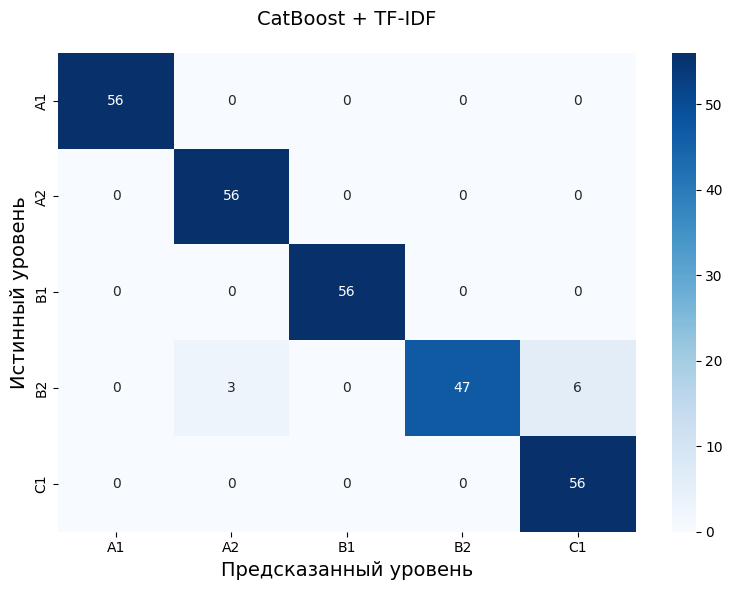

In [ ]:
# Визуализация результатов с помощью матрицы путаницы

y_pred = catboost_tfidf.predict(X_test_tfidf)
cm_tfidf= confusion_matrix(y_test, y_pred, labels = levels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_tfidf,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=levels,
            yticklabels=levels)

plt.title('CatBoost + TF-IDF', fontsize=14, pad=20)
plt.xlabel('Предсказанный уровень', fontsize=14)
plt.ylabel('Истинный уровень', fontsize=14)
plt.tight_layout()
plt.show()

Для оптимизации ситуации я воспользовалась способом кодирования текстов с помощью предложенной преподавателем модели BERT,обученной на базе трансформера.

In [ ]:
from transformers import BertTokenizer, BertModel

In [ ]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained("bert-base-uncased")
model.eval()

In [ ]:
# Применим предобученную модель Bert к тренировочным данным

# Напишем функцию для получения эмбеддингов:

def get_embeddings(texts):
    embeddings = []

    for i, text in enumerate(texts):
        encoded_input = tokenizer(text,
                                  return_tensors='pt',
                                  truncation=True,
                                  max_length=128)



        # так как Bert уже предобучен, в вычислении градиента нет необходимости.

        with torch.no_grad():
            output = model(**encoded_input)
            cls_embedding = output.last_hidden_state[0, 0, :].numpy()  # [CLS] маркер используется для агрегации контекстной информации всего текста.
            embeddings.append(cls_embedding)

    # Преобразуем в numpy массив для дальнейшей работы с CatBoost.

    return np.array(embeddings)


In [ ]:
# Получаем эмбеддинги для тренировочных и тестовых данных.

X_train_bert = get_embeddings(X_train)
X_test_bert = get_embeddings(X_test)

In [ ]:
# Сохраним эмбеддинги.

np.save('/content/drive/MyDrive/Colab Notebooks/bert_embeddings_train.npy', X_train_bert)
np.save('/content/drive/MyDrive/Colab Notebooks/bert_embeddings_test.npy', X_test_bert)

In [ ]:
X_train_bert

array([[ 0.02315869,  0.06515092, -0.12963225, ..., -0.13146009,
         0.7023931 ,  0.38443524],
       [-0.2991272 , -0.13127618,  0.14668494, ..., -0.21176937,
         0.72199005, -0.06717053],
       [-0.1431693 , -0.13563073,  0.5183906 , ..., -0.6120451 ,
         0.844818  ,  0.28620484],
       ...,
       [-0.28011334, -0.15703565,  0.14634016, ..., -0.16329531,
         1.0137    ,  0.09803803],
       [-0.28724453, -0.0619022 , -0.07195623, ..., -0.09413414,
         0.07912689,  0.58849233],
       [ 0.09244864,  0.23530415,  0.4071586 , ..., -0.16780387,
         0.44896132,  0.8280924 ]], dtype=float32)

In [ ]:
# Перейдем к реализации модели CatBoost уже на эмбеддингах.

catboost_bert = CatBoostClassifier(iterations=200,
                           learning_rate=0.1,
                           depth=6,
                           early_stopping_rounds=50,
                           random_seed=42)

catboost_bert.fit(X_train_bert, y_train)

0:	learn: 1.5532614	total: 3.36s	remaining: 11m 8s
1:	learn: 1.4915441	total: 4.63s	remaining: 7m 38s
2:	learn: 1.4420128	total: 5.88s	remaining: 6m 26s
3:	learn: 1.3929588	total: 6.92s	remaining: 5m 39s
4:	learn: 1.3474490	total: 7.65s	remaining: 4m 58s
5:	learn: 1.3072988	total: 8.42s	remaining: 4m 32s
6:	learn: 1.2727501	total: 9.17s	remaining: 4m 12s
7:	learn: 1.2429885	total: 9.9s	remaining: 3m 57s
8:	learn: 1.2140898	total: 10.7s	remaining: 3m 46s
9:	learn: 1.1773774	total: 11.5s	remaining: 3m 37s
10:	learn: 1.1442512	total: 12.2s	remaining: 3m 30s
11:	learn: 1.1178150	total: 13s	remaining: 3m 22s
12:	learn: 1.0895801	total: 13.7s	remaining: 3m 17s
13:	learn: 1.0630921	total: 14.5s	remaining: 3m 12s
14:	learn: 1.0403914	total: 15.2s	remaining: 3m 7s
15:	learn: 1.0199218	total: 16s	remaining: 3m 3s
16:	learn: 0.9952415	total: 16.8s	remaining: 3m
17:	learn: 0.9774590	total: 18s	remaining: 3m 2s
18:	learn: 0.9575874	total: 19.3s	remaining: 3m 3s
19:	learn: 0.9397152	total: 20.6s	rem

CatBoostClassifier(depth=6, early_stopping_rounds=50, iterations=200, learning_rate=0.1, random_seed=42)

In [ ]:
# Сохраняем модель.

joblib.dump(catboost_bert, '/content/drive/MyDrive/Colab Notebooks/catboost_bert_model.joblib')

['/content/drive/MyDrive/Colab Notebooks/catboost_bert_model.joblib']

In [ ]:
# Оценим производительность обученной модели на тестовых данных.

accuracy = catboost_bert.score(X_test_bert, y_test)
accuracy

np.float64(0.8642857142857143)

In [ ]:
# Посмотрим более подробный отчет.

y_pred = catboost_bert.predict(X_test_bert)
print(classification_report(y_test, y_pred,
                           target_names=levels))

              precision    recall  f1-score   support

          A1       0.89      0.91      0.90        56
          A2       0.90      0.82      0.86        56
          B1       0.84      0.91      0.87        56
          B2       0.85      0.80      0.83        56
          C1       0.84      0.88      0.86        56

    accuracy                           0.86       280
   macro avg       0.87      0.86      0.86       280
weighted avg       0.87      0.86      0.86       280



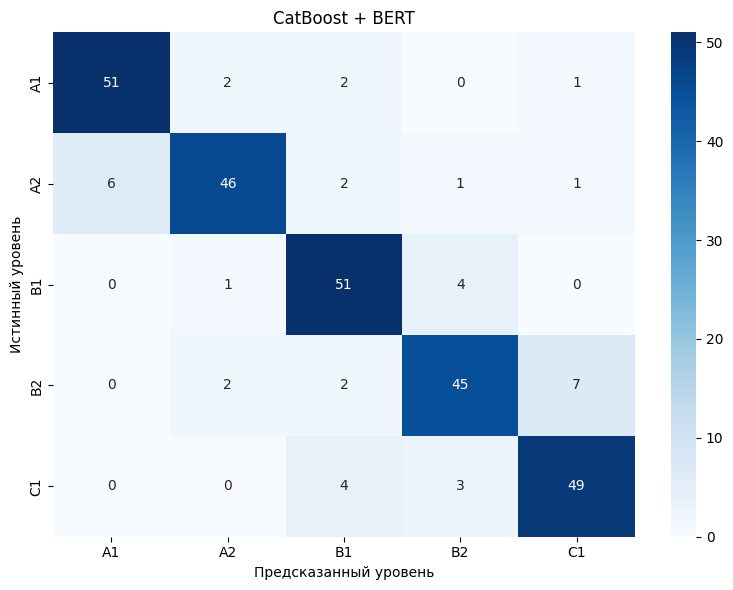

In [ ]:
# Посмотрим на матрицу ошибок
cm_bert = confusion_matrix(y_test, y_pred, labels=levels)

# Визуализация
plt.figure(figsize=(8, 6))
sns.heatmap(cm_bert, annot=True, fmt='d', cmap='Blues',
            xticklabels=levels,
            yticklabels=levels)
plt.title(f'CatBoost + BERT')
plt.ylabel('Истинный уровень')
plt.xlabel('Предсказанный уровень')
plt.tight_layout()
plt.show()

Я сравнила два способа подготовки текстов для определения их уровня сложности:
1) Векторизация с помощью TF-IDF (то есть было подсчитано, какие слова чаще всего встречаются в текстах каждого уровня)
2) Кодировка текстов в эмбеддинги с помощью предобученой модели BERT (она хорошо умеет анализировать контексты)

Эти подготовленные наборы данных я подала в CatBoost. Результаты:

1) TF-IDF + CatBoost показал 96.8% точности. Результат очень высокий, соответственно, подозрительный.
2) BERT + CatBoost показал 86% точности.
A1, B1, C1 определяются хорошо (88-91% точности).
A2 иногда путается с A1 (тексты на границе уровней).
B2 оказался самым сложным, так как это "переходный" уровень: часть текстов уже тянется к C1, часть еще похожа на B1.

TF-IDF показал завышенный результат (96.8%), потому что нашел поверхностные закономерности: длину текстов, частотность определенных слов, структуру предложений. Модель определяла уровень по внешним признакам, а не по реальной сложности текста. BERT же, благодаря пониманию контекста, выдал реалистичную оценку в 86%, которую можно считать настоящей точностью классификации.